# Heart Disease UCI — Exploratory Data Analysis

## Overview
This notebook contains an exploratory data analysis (EDA) of the UCI Heart Disease dataset,
combining data from 4 hospitals: Cleveland, Hungary, Switzerland, and VA Long Beach.

**Dataset:** 920 patients, 15 variables (clinical and demographic)  
**Target variable:** `num`: disease severity (0 = no disease, 1-4 = increasing severity)  
**Goal:** Understand the distribution of variables and identify patterns associated with heart disease.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("heart_disease_uci.csv", index_col= 0)

df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 1. Data Exploration
Initial inspection of the dataset.

In [3]:
print(df.info())
print(df.describe())
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 920 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 115.0+ KB
None
              age    trestbps        chol      thalch     oldpeak          ca  \
count  920.000000  861.000000  890.000000  865.000000  858.000000  309.000000   
mean  

## 2. Data Cleaning
Two variables contain physiologically impossible zero values:
- `trestbps` (resting blood pressure) — a value of 0 mmHg is not possible in a living patient
- `chol` (serum cholesterol) — a value of 0 mg/dl is not physiologically valid

These zeros are replaced with `NaN` to be treated as missing values in subsequent analysis.

In [4]:
df_raw = df.copy()
df_clean = df.copy()
df_clean.loc[df_clean.trestbps == 0, 'trestbps'] = np.nan
df_clean.loc[df_clean.chol == 0, 'chol'] = np.nan

In [5]:
print("Soma dos valores em falta:")
df_clean.isnull().sum()

Soma dos valores em falta:


age           0
sex           0
dataset       0
cp            0
trestbps     60
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

## 3. Missing Value Analysis
Three variables have substantial missing data: `ca`, `thal`, and `slope`.
We investigate whether this missingness is random or systematically related
to disease severity and hospital of origin, an important distinction for
future modelling.

### 3.1 Missingness by disease status
We compare the proportion of missing values between healthy patients (num=0)
and analyse if general severity of the disease justifys missing values.

In [6]:
healthy_total = df_clean.num[df_clean.num == 0].count()
healthy_ca_null_percent =  df_clean.num[(df_clean.num == 0) & (df_clean.ca.isnull())].count()
healthy_thal_null_percent =  df_clean.num[(df_clean.num == 0) & (df_clean.thal.isnull())].count()
healthy_slop_null_percent =  df_clean.num[(df_clean.num == 0) & (df_clean.slope.isnull())].count()

print("Total:", healthy_total,
    "\nhealthy ca is null:", healthy_ca_null_percent/healthy_total, "%",
    "\nhealthy thal is null:", healthy_thal_null_percent/healthy_total, "%",
    "\nhealthy slop is null:", healthy_slop_null_percent/healthy_total, "%",)

Total: 411 
healthy ca is null: 0.5985401459854015 % 
healthy thal is null: 0.5450121654501217 % 
healthy slop is null: 0.46958637469586373 %


In [7]:
general_mean_target = df_clean.num.mean()
ca_mean_target = df_clean.num[df_clean.ca.isnull()].mean()
thal_mean_target = df_clean.num[df_clean.thal.isnull()].mean()
slope_mean_target = df_clean.num[df_clean.slope.isnull()].mean()

print('{} gerneral mean vs {} ca mean vs {} thal mean vs {} slope_mean'.format(general_mean_target, ca_mean_target, thal_mean_target, slope_mean_target))

0.9956521739130435 gerneral mean vs 1.0196399345335516 ca mean vs 0.8930041152263375 thal mean vs 0.6440129449838188 slope_mean


### 3.2 Missingness in patients with heart disease
Same analysis repeated specifically for the disease group,
to check if missingness correlates with disease severity within that group.

In [8]:
hasdisease_total = df_clean.num[df_clean.num>0].count()
unhealthy_ca_null_percent =  df_clean.num[(df_clean.num > 0) & (df_clean.ca.isnull())].count()
unhealthy_thal_null_percent =  df_clean.num[(df_clean.num > 0) & (df_clean.thal.isnull())].count()
unhealthy_slope_null_percent =  df_clean.num[(df_clean.num > 0) & (df_clean.slope.isnull())].count()

print("Total:", hasdisease_total,
    "\nunhealthy ca is null:", unhealthy_ca_null_percent/hasdisease_total, "%",
    "\nunhealthy thal is null:", unhealthy_thal_null_percent/hasdisease_total, "%",
    "\nunhealthy slope is null:", unhealthy_slope_null_percent/hasdisease_total, "%")

Total: 509 
unhealthy ca is null: 0.7170923379174853 % 
unhealthy thal is null: 0.5147347740667977 % 
unhealthy slope is null: 0.22789783889980353 %


In [9]:
df_hasdisease = df_clean.loc[df.num>0]
general_mean_disease = df_hasdisease.num.mean()
ca_mean_disease = df_hasdisease.num[df_hasdisease.ca.isnull()].mean()
thal_mean_disease = df_hasdisease.num[df_hasdisease.thal.isnull()].mean()
slope_mean_disease = df_hasdisease.num[df_hasdisease.slope.isnull()].mean()

print('{} gerneral mean vs {} ca mean vs {} thal mean vs {} slope_mean'.format(general_mean_disease, ca_mean_disease, thal_mean_disease, slope_mean_disease))

1.799607072691552 gerneral mean vs 1.7068493150684931 ca mean vs 1.6564885496183206 thal mean vs 1.7155172413793103 slope_mean


### 3.3 Missingness by hospital
Different hospitals may have collected data differently.
We use `groupby` to calculate the missing rate per hospital,
and `crosstab` to check if missingness is associated with disease severity.

In [10]:
hospital_miss_ca = df_clean.groupby('dataset')['ca'].apply(lambda x: x.isnull().mean())
miss_severity_ca = pd.crosstab(df_clean.ca.isnull(), df_clean.num, normalize='index')

hospital_miss_thal = df_clean.groupby('dataset')['thal'].apply(lambda x: x.isnull().mean())
miss_severity_thal = pd.crosstab(df_clean.thal.isnull(), df_clean.num, normalize='index')

hospital_miss_slope = df_clean.groupby('dataset')['slope'].apply(lambda x: x.isnull().mean())
miss_severity_slope = pd.crosstab(df_clean.slope.isnull(), df_clean.num, normalize='index')

print("For ca:")
print(hospital_miss_ca)
print(miss_severity_ca)
print("")
print("For thal:")
print(hospital_miss_thal)
print(miss_severity_thal)
print("")
print("For slope:")
print(hospital_miss_slope)
print(miss_severity_slope)

For ca:
dataset
Cleveland        0.016447
Hungary          0.989761
Switzerland      0.959350
VA Long Beach    0.990000
Name: ca, dtype: float64
num           0         1         2         3         4
ca                                                     
False  0.533981  0.187702  0.116505  0.119741  0.042071
True   0.402619  0.338789  0.119476  0.114566  0.024550

For thal:
dataset
Cleveland        0.009868
Hungary          0.904437
Switzerland      0.422764
VA Long Beach    0.830000
Name: thal, dtype: float64
num           0        1         2         3         4
thal                                                  
False  0.430876  0.24424  0.145161  0.142857  0.036866
True   0.460905  0.32716  0.094650  0.092593  0.024691

For slope:
dataset
Cleveland        0.003289
Hungary          0.645051
Switzerland      0.138211
VA Long Beach    0.510000
Name: slope, dtype: float64
num           0         1         2         3         4
slope                                                

### Key findings — Missing values

- **`ca`, `thal` and `slope`** are missing predominantly in non-Cleveland hospitals,
suggesting data collection differences between sites rather than random missingness.
- However, missing values in `slope` appear to be **informatively missing** -
the proportion of missing values is higher in healthy patients, suggesting
this variable was less likely to be recorded when no cardiac abnormality was detected.
This means the missingness itself carries clinical information.
- Missingness appears to be **Missing Not At Random (MNAR)** - the probability
of a value being missing is related to the hospital of origin and potentially
to disease severity.
- For future modelling, rows with missing `ca`, `thal`, or `slope` should not
be dropped without careful consideration, as this could introduce bias.

## 4. Univariate Analysis
Distribution of each variable across the full dataset.
This gives us a first look at the data before examining relationships with the target.

## 4.1 Add new column
Added `num_labels` for readability on plots

In [11]:
num_labels = {0:"No disease", 1: "Mild", 2:"Moderate", 3:"Severe", 4:"Very Severe"}
df_clean["num_labels"] = df_clean.num.map(num_labels)

In [12]:
def plot_hist(ax, column,title,x_label, color, bins=20, df = None):
    if df is None:
        df = df_clean
    ax.hist(df[column], bins = bins, edgecolor='white', color = color)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Count")

def plot_bar(ax, column, order, title, x_label, color, df  = None):
    if df is None:
        df = df_clean
    count = df[column].astype(str).value_counts().reindex(order, fill_value = 0)
    ax.bar(order, count.values, color = color)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Count")

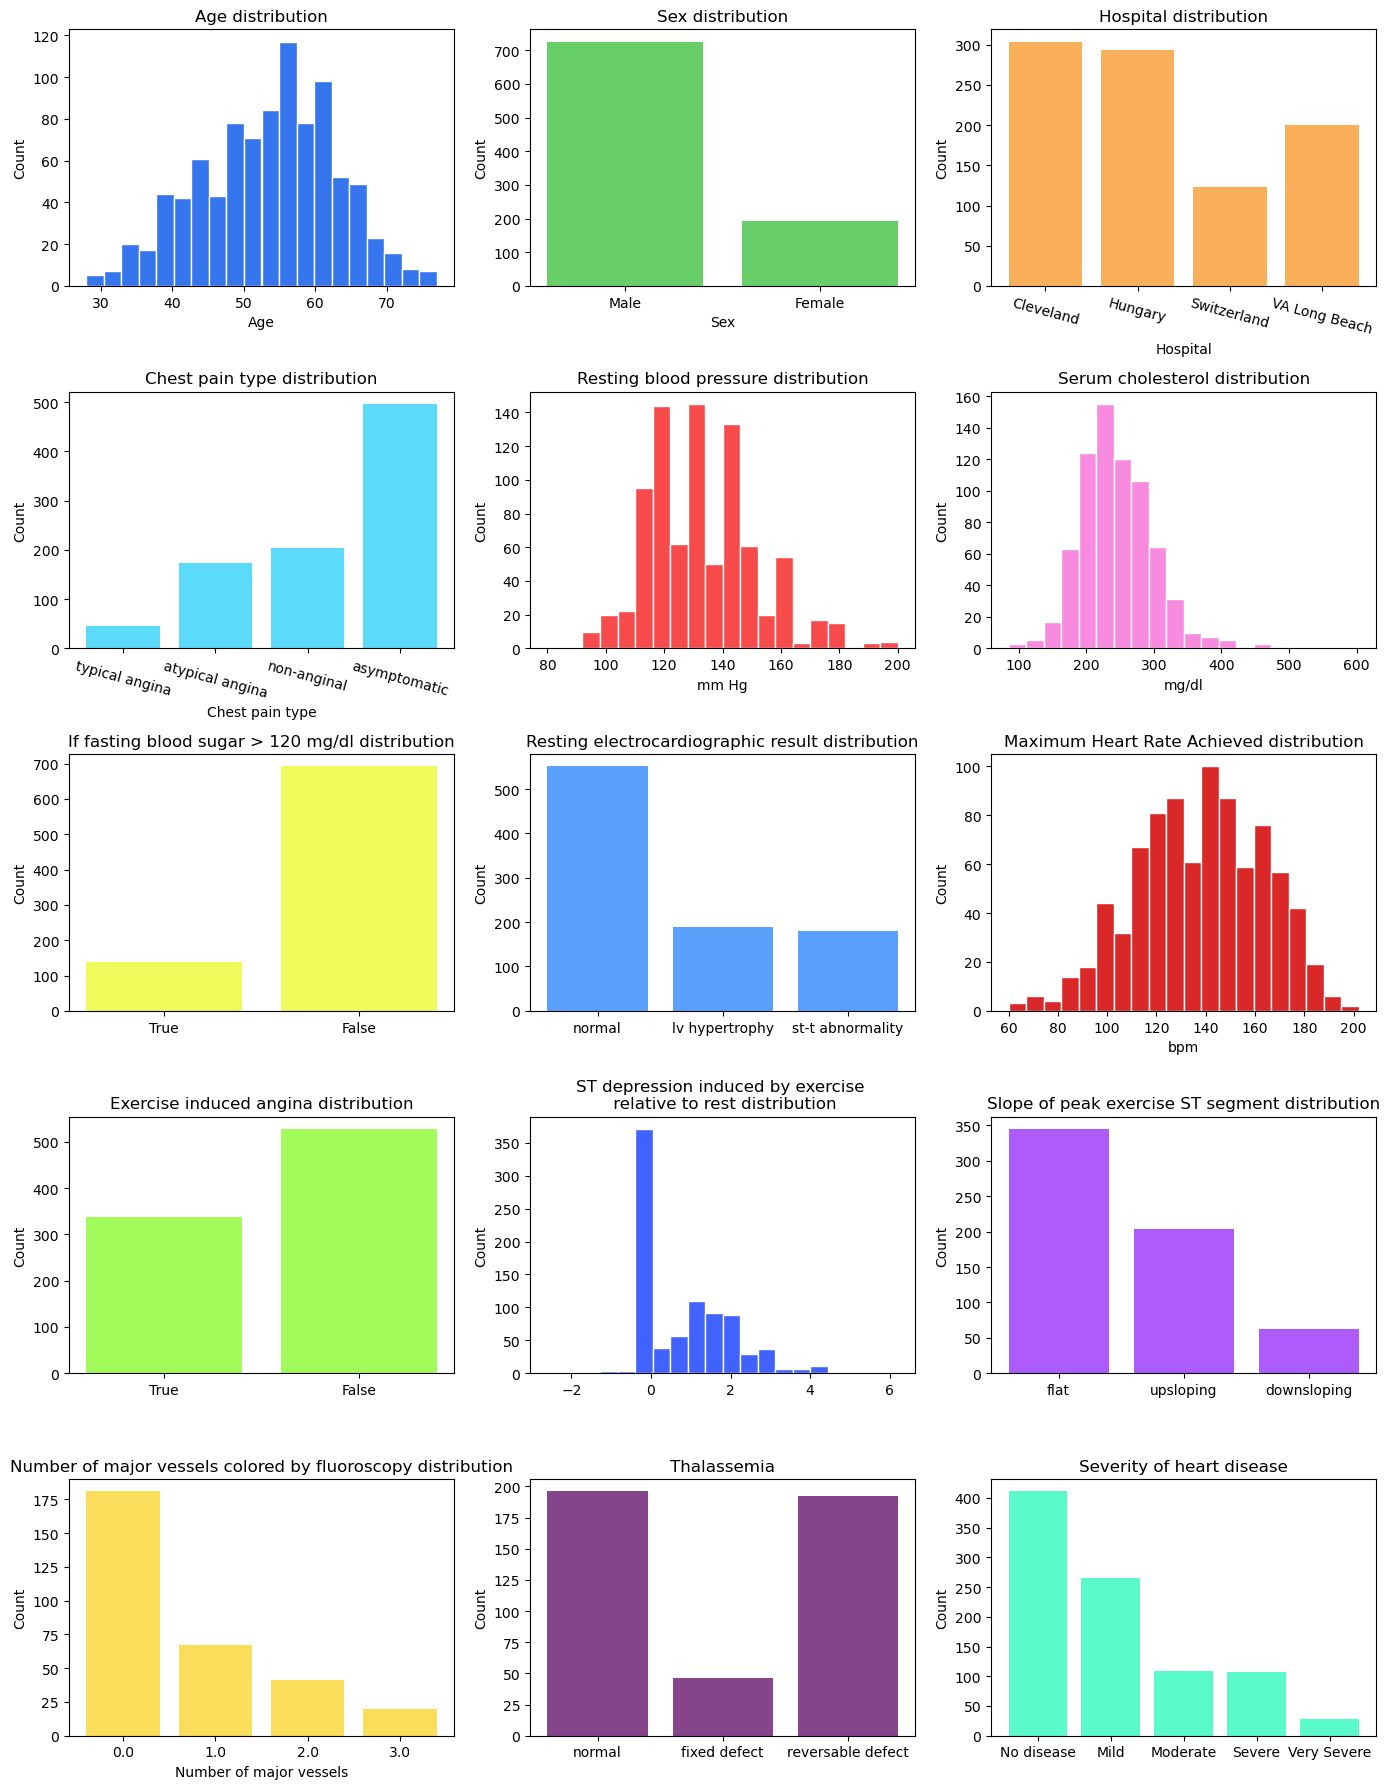

In [13]:
fig, ax = plt.subplots(5, 3, figsize =(14,18))

plot_hist(ax[0,0], "age", "Age distribution","Age","#3576EE" )

plot_bar(ax[0,1], "sex", 
         order = ["Male", "Female"], 
         title="Sex distribution",
         x_label="Sex",
         color="#68CF68")

plot_bar(ax[0,2], "dataset", 
         order = ["Cleveland", "Hungary","Switzerland","VA Long Beach"], 
         title="Hospital distribution",
         x_label="Hospital",
         color="#FAB05B")
ax[0,2].tick_params(axis = "x", rotation = -15)

plot_bar(ax[1,0], "cp", 
         order = ["typical angina", "atypical angina","non-anginal", "asymptomatic"], 
         title="Chest pain type distribution",
         x_label="Chest pain type",
         color="#5BDAFA")
ax[1,0].tick_params(axis = "x", rotation = -15)

plot_hist(ax[1,1], "trestbps", "Resting blood pressure distribution","mm Hg","#F74A4A")

plot_hist(ax[1,2], "chol", "Serum cholesterol distribution","mg/dl","#F88BE0")

plot_bar(ax[2,0], "fbs", 
         order = ["True", "False"], 
         title="If fasting blood sugar > 120 mg/dl distribution",
         x_label="",
         color="#EFFA5B")

plot_bar(ax[2,1], "restecg", 
         order = ["normal", "lv hypertrophy","st-t abnormality"], 
         title="Resting electrocardiographic result distribution",
         x_label="",
         color="#5BA0FA")

plot_hist(ax[2,2], "thalch", "Maximum Heart Rate Achieved distribution","bpm","#DA2828")

plot_bar(ax[3,0], "exang", 
         order = ["True", "False"], 
         title="Exercise induced angina distribution",
         x_label="",
         color="#A2FA5B")

plot_hist(ax[3,1], "oldpeak", "ST depression induced by exercise \n relative to rest distribution","","#4063FF")


plot_bar(ax[3,2], "slope", 
         order = ["flat", "upsloping", "downsloping"], 
         title="Slope of peak exercise ST segment distribution",
         x_label="",
         color="#AD5BFA")

plot_bar(ax[4,0], "ca", 
         order = ["0.0", "1.0", "2.0", "3.0"], 
         title="Number of major vessels colored by fluoroscopy distribution",
         x_label="Number of major vessels",
         color="#FADD5B")

plot_bar(ax[4,1], "thal", 
         order = ["normal", "fixed defect", "reversable defect"], 
         title="Thalassemia",
         x_label="",
         color="#86448B")

plot_bar(ax[4,2], "num_labels", 
         order = ["No disease", "Mild", "Moderate", "Severe", "Very Severe"], 
         title="Severity of heart disease",
         x_label="",
         color="#5BFACA")


plt.tight_layout()
plt.savefig('analysis_univariate.png', dpi=150)
plt.show()


## 5. Bivariate Analysis
Examination of each variable with the target `num`.

In [15]:
def plot_box(data, x, y, ax, palette, title, x_label, legend=False):
    sns.boxplot(data = data, x = x, y = y, hue = x, ax = ax, palette = palette, legend=legend)
    ax.set_title(title)
    ax.set_xticks(range(len(x_label)))
    ax.set_xticklabels(x_label)
    ax.tick_params(axis = "x", rotation = -15)
    ax.set_xlabel("")

def plot_count(data, x, hue, ax, pallette, title, x_label):
    counts = data.groupby([x, hue]).size().reset_index(name="count")
    group_totals = data.groupby(x).size().reset_index(name="total")
    counts = counts.merge(group_totals, on=x)
    counts["proportion"] = counts["count"] / counts["total"]

    sns.barplot(
        data=counts, x=x, hue=hue, y="proportion", ax=ax, palette=pallette)
    ax.set_title(title)
    ax.set_xticks(range(len(x_label)))
    ax.set_xticklabels(x_label)
    ax.tick_params(axis="x", rotation=-15)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")

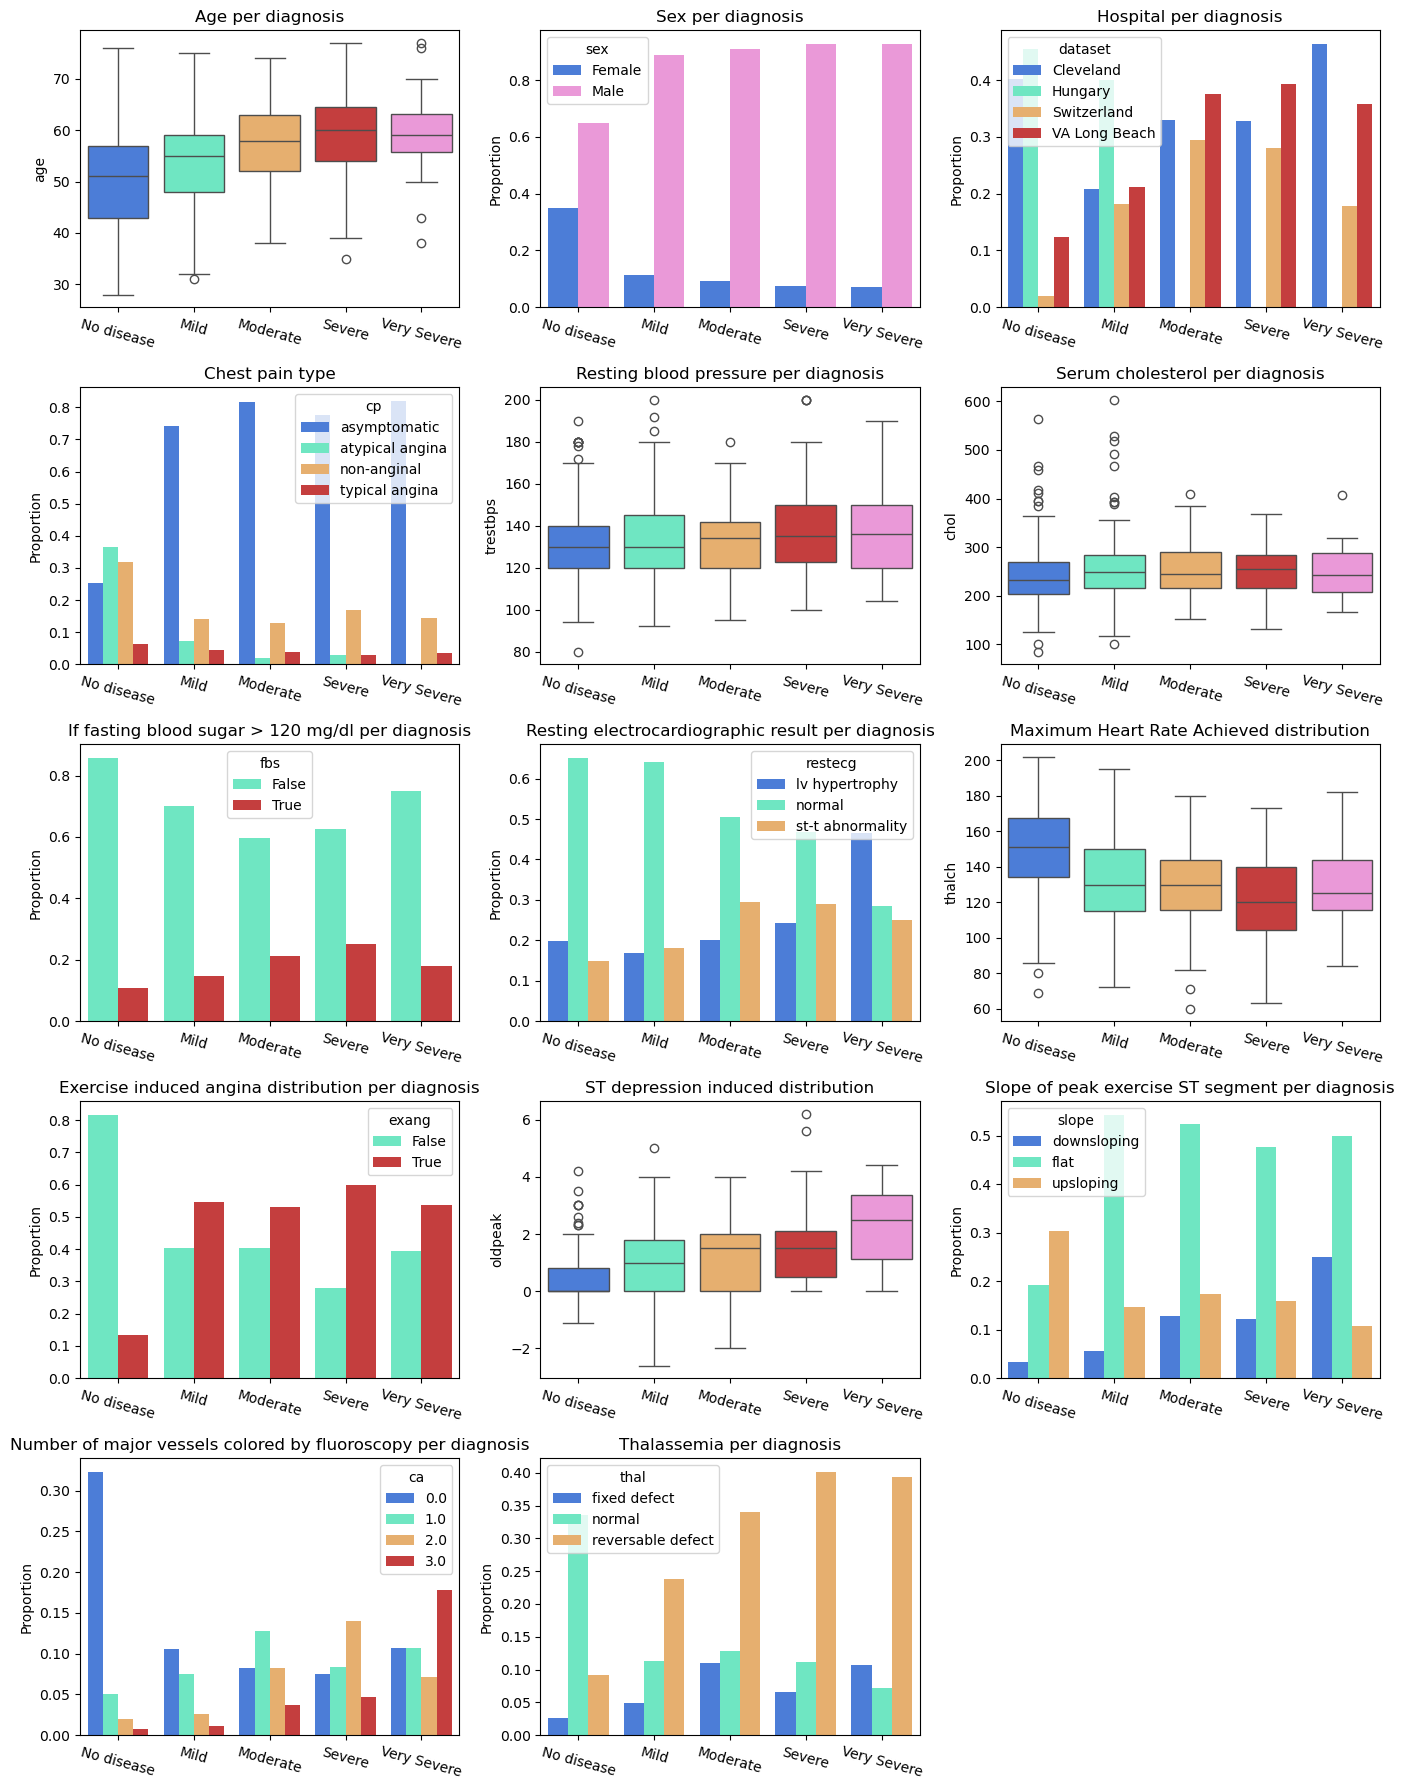

In [ ]:
fig, ax = plt.subplots(5, 3, figsize =(14,18))

x_label = ["No disease", "Mild", "Moderate", "Severe", "Very Severe"]
pallette1 = ["#3576EE","#5BFACA","#FAB05B","#DA2828","#F88BE0"]
pallette2 = ["#3576EE","#F88BE0"] 
pallette3 = ["#5BFACA","#DA2828"]
pallette4 = ["#3576EE","#5BFACA","#FAB05B"]
pallette5 = ["#3576EE","#5BFACA","#FAB05B","#DA2828"]

plot_box(df_clean, "num", "age", ax[0,0], pallette1 , "Age per diagnosis", x_label)

plot_count(df_clean, "num", "sex", ax[0,1], pallette2, "Sex per diagnosis", x_label)

plot_count(df_clean, "num", "dataset", ax[0,2], pallette5, "Hospital per diagnosis", x_label)

plot_count(df_clean, "num", "cp", ax[1,0], pallette5, "Chest pain type", x_label)

plot_box(df_clean, "num", "trestbps", ax[1,1], pallette1 , "Resting blood pressure per diagnosis", x_label)

plot_box(df_clean, "num", "chol", ax[1,2], pallette1 , "Serum cholesterol per diagnosis", x_label)

plot_count(df_clean, "num", "fbs", ax[2,0], pallette3 , "If fasting blood sugar > 120 mg/dl per diagnosis", x_label)

plot_count(df_clean, "num", "restecg", ax[2,1], pallette4 , "Resting electrocardiographic result per diagnosis", x_label)

plot_box(df_clean, "num", "thalch", ax[2,2], pallette1 , "Maximum Heart Rate Achieved distribution", x_label)

plot_count(df_clean, "num", "exang", ax[3,0], pallette3 , "Exercise induced angina distribution per diagnosis", x_label)

plot_box(df_clean, "num", "oldpeak", ax[3,1], pallette1 , "ST depression induced distribution", x_label)

plot_count(df_clean, "num", "slope", ax[3,2], pallette4 , "Slope of peak exercise ST segment per diagnosis", x_label)

plot_count(df_clean, "num", "ca", ax[4,0], pallette5 , "Number of major vessels colored by fluoroscopy per diagnosis", x_label)

plot_count(df_clean, "num", "thal", ax[4,1], pallette4 , "Thalassemia per diagnosis", x_label)

ax[4,2].set_axis_off()



plt.tight_layout()
plt.savefig('analysis_bivariate.png', dpi=150)
plt.show()

## 6. Correlation Heatmap
To quantify the relationships observed in the bivariate analysis, we compute the
Spearman correlation between all numeric variables and `binary_num` (binary: 0 = no disease, 1 = disease) 
and `num` (0 = no disease, 1-4 = increasing severity).

>**Note:** Only numeric variables are included. Categorical variables such as `cp`,
>`thal`, and `slope` are excluded from this matrix but were analysed in the bivariate section.

## 6.1. Add binary `num` column
Added a binary `num` column for correlation analysis

In [ ]:
df_clean["Binary_num"] = (df_clean.num>0).astype(int)

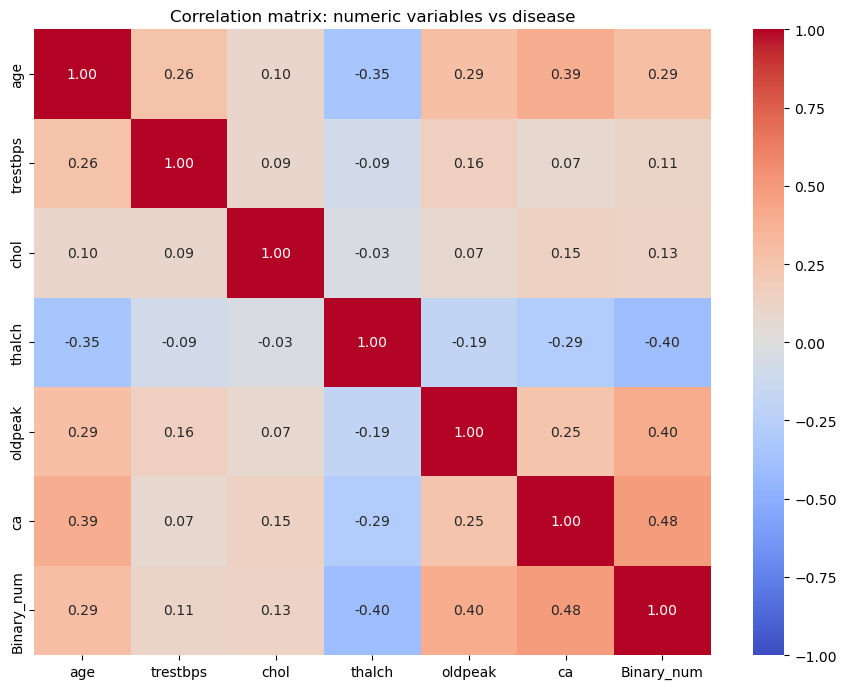

In [18]:
corr1 = df_clean[["age", "trestbps", "chol", "thalch", 
                  "oldpeak", "ca", "Binary_num"]].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr1, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, vmin=-1, vmax=1)        
plt.title('Correlation matrix: numeric variables vs disease')

plt.tight_layout()
plt.savefig('correlation_presence.png', dpi=150)
plt.show()

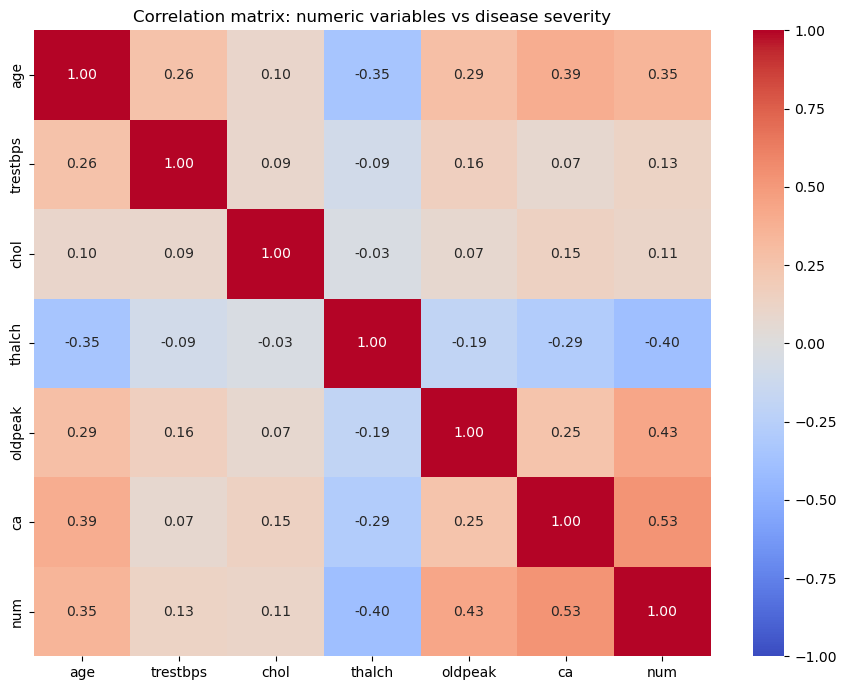

In [19]:
plt.figure(figsize=(9, 7))

corr2 = df_clean[["age", "trestbps", "chol", "thalch", 
                  "oldpeak", "ca", "num"]].corr(method='spearman')

sns.heatmap(corr2, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix: numeric variables vs disease severity')

plt.tight_layout()
plt.savefig('correlation_severity.png', dpi=150)
plt.show()

## Conclusion of EDA

1. **`ca` is the strongest predictor** - number of major vessels colored by 
fluoroscopy shows the highest correlation with both disease presence (0.48) 
and severity (0.53).

2. **Most variables correlate more strongly with severity than with disease presence** -
This may suggests that for most variables, the continuous severity scale (0-4) captures 
more clinical signal than a simple disease/no disease split.

3. **`chol` and `trestbps` are weak predictors** - contrary to common 
assumption, cholesterol and resting blood pressure show near-zero correlation 
with disease presence, suggesting they are insufficient as standalone predictors.

4. **Asymptomatic chest pain is the dominant type in disease patients** - 
counterintuitively, patients with heart disease most commonly report no chest 
pain, which has important implications for clinical screening.

5. **Missing data is not random** - missingness in `ca`, `thal`, and `slope`
is concentrated in non-Cleveland hospitals, suggesting systematic differences
in data collection across sites that must be accounted for in any future model.
Some missingness may also reflect clinical decision-making - variables such as
`slope` were less frequently recorded in patients showing no cardiac abnormality,
suggesting the test was not performed when deemed unnecessary.

6. **Dataset is heavily skewed** - The vast majority of pacients are healthy, only
28 pacients being within the category "Very Severe". Important to note for future
modeling.

> **Note:** Plots for `ca`, `thal`, and `slope` exclude most patients 
> due to missing values. Patterns observed in these variables should be 
> interpreted with caution.